In [1]:
# Add project folder to sys.path
import sys
from pathlib import Path
project_path = Path(r"C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor")
sys.path.append(str(project_path))

### Imports

In [2]:
import tensorflow as tf
import torch

print("TensorFlow version:", tf.__version__)
print("TensorFlow GPUs:", tf.config.list_physical_devices("GPU"))

print("PyTorch version:", torch.__version__)
print("PyTorch CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("PyTorch GPU:", torch.cuda.get_device_name(0))

TensorFlow version: 2.20.0
TensorFlow GPUs: []
PyTorch version: 2.11.0+cpu
PyTorch CUDA available: False


In [3]:
from first_year_persistance_classification.utils.data_cleaner import DataCleaner
from skimpy import skim
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix


sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110})

In [34]:
# --- Helper functions ------
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)


def safe_binary_roc_auc(y_true, y_prob):
    try:
        return float(roc_auc_score(y_true, y_prob))
    except ValueError:
        return float("nan")


def evaluate_classification_model(model_obj, X_split, y_split, split_name, model_name=None, threshold=0.5, batch_size=256):
    y_true = np.asarray(y_split).astype(int).ravel()
    eval_values = model_obj.evaluate(X_split, y_split, batch_size=batch_size, verbose=0)

    if isinstance(eval_values, (list, tuple, np.ndarray)):
        loss = float(eval_values[0])
        accuracy = float(eval_values[1]) if len(eval_values) > 1 else np.nan
    else:
        loss = float(eval_values)
        accuracy = np.nan

    y_prob = model_obj.predict(X_split, batch_size=batch_size, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "Split": split_name,
        "Loss": loss,
        "Accuracy": accuracy if not np.isnan(accuracy) else float(accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "ROC AUC": safe_binary_roc_auc(y_true, y_prob),
    }

    if model_name is not None:
        metrics["Model"] = model_name

    return metrics


def evaluate_classification_splits(model_obj, split_specs, model_name=None, threshold=0.5, batch_size=256):
    rows = [
        evaluate_classification_model(
            model_obj,
            X_split,
            y_split,
            split_name,
            model_name=model_name,
            threshold=threshold,
            batch_size=batch_size,
        )
        for split_name, X_split, y_split in split_specs
    ]

    metric_df = pd.DataFrame(rows)
    ordered_columns = ["Split", "Loss", "Accuracy", "Precision", "Recall", "F1", "ROC AUC"]
    if model_name is not None:
        ordered_columns = ["Model"] + ordered_columns
    return metric_df[ordered_columns].copy()


def plot_train_test_evaluation(
    model_obj,
    X_train_scaled,
    y_train_original,
    X_val_scaled=None,
    y_val_original=None,
    X_test_scaled=None,
    y_test_original=None,
    class_names=("Not Persisted", "Persisted"),
    title="MODEL EVALUATION",
    threshold=0.5,
    batch_size=256,
):
    """Plot confusion matrices and classification reports for train, validation, and test splits."""
    split_specs = [("Train", X_train_scaled, y_train_original)]
    if X_val_scaled is not None and y_val_original is not None:
        split_specs.append(("Validation", X_val_scaled, y_val_original))
    if X_test_scaled is not None and y_test_original is not None:
        split_specs.append(("Test", X_test_scaled, y_test_original))

    fig, axes = plt.subplots(2, len(split_specs), figsize=(5 * len(split_specs), 10), dpi=90, constrained_layout=True)
    fig.suptitle(title, fontsize=14, fontweight="bold")

    if len(split_specs) == 1:
        axes = np.array(axes).reshape(2, 1)

    report_rows = list(class_names) + ["macro avg", "weighted avg"]

    for col_idx, (split_name, X_split, y_split) in enumerate(split_specs):
        y_true = np.asarray(y_split).astype(int).ravel()
        y_pred = (model_obj.predict(X_split, batch_size=batch_size, verbose=0).ravel() >= threshold).astype(int)
        cm = confusion_matrix(y_true, y_pred)

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names,
            ax=axes[0, col_idx],
        )
        axes[0, col_idx].set_title(f"{split_name} - Confusion Matrix")
        axes[0, col_idx].set_xlabel("Predicted")
        axes[0, col_idx].set_ylabel("Actual")

        accuracy = accuracy_score(y_true, y_pred)
        report = classification_report(
            y_true,
            y_pred,
            target_names=list(class_names),
            output_dict=True,
            zero_division=0,
        )
        report_df = pd.DataFrame(report).transpose().loc[report_rows, ["precision", "recall", "f1-score"]]
        sns.heatmap(report_df, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[1, col_idx])
        axes[1, col_idx].set_title(f"{split_name} - Classification Report\nAccuracy={accuracy:.3f}")
        axes[1, col_idx].set_xlabel("Metrics")
        axes[1, col_idx].set_ylabel("Classes")

    plt.show()


def plot_roc_curves(
    model_obj,
    X_train_scaled,
    y_train_original,
    X_val_scaled=None,
    y_val_original=None,
    X_test_scaled=None,
    y_test_original=None,
    title="ROC Curves - Train vs Validation vs Test",
    batch_size=256,
):
    split_specs = [("Train", X_train_scaled, y_train_original)]
    if X_val_scaled is not None and y_val_original is not None:
        split_specs.append(("Validation", X_val_scaled, y_val_original))
    if X_test_scaled is not None and y_test_original is not None:
        split_specs.append(("Test", X_test_scaled, y_test_original))

    plt.figure(figsize=(8, 6))
    for split_name, X_split, y_split in split_specs:
        y_prob = model_obj.predict(X_split, batch_size=batch_size, verbose=0).ravel()
        fpr, tpr, _ = roc_curve(np.asarray(y_split).astype(int).ravel(), y_prob)
        split_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{split_name} (AUC={split_auc:.3f})", linewidth=2)

    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Data Acquisition

In [4]:
# Load the structured dataset
structured_data_file = project_path / "data/structured_student_data.csv"
clean_df = pd.read_csv(structured_data_file)

# Observe the dataset
skim(clean_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1437   │ │ string      │ 8     │                                                          │
│ │ Number of columns │ 15     │ │ float64     │ 7     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                    ┃ NA  ┃ NA %   ┃ mean     ┃ sd       ┃ p0  ┃ p25  ┃ p50  ┃ p75  ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ funding                   │   0 │      0 │    2.927 │    1.258 │   1 │    2 │    2 │    4 │     9 │  ▇ ▆   │  │
│ │ school                    │   0 │      0 │        6 │        0 │   6 │    6 │    6 │    6 │     6 │     ▇  │  │
│ │ fast_track                │   0 │      0 │    1.742 │   0.4378 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ coop                      │   0 │      0 │    1.695 │   0.4605 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ residency                 │   0 │      0 │    1.406 │   0.4913 │   1 │    1 │    1 │    2 │     2 │ ▇    ▅ │  │
│ │ gender                    │   0 │      0 │    1.775 │   0.4197 │   1 │    2 │    2 │    2 │     3 │  ▂  ▇  │  │
│ │ first_year_persistence    │   0 │      0 │   0.7919 │   0.4061 │   0 │    1 │    1 │    1 │     1 │ ▂    ▇ │  │
│ └───────────────────────────┴─────┴────────┴──────────┴──────────┴─────┴──────┴──────┴──────┴───────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃ column         ┃ NA ┃ NA % ┃ shortest ┃ longest  ┃ min ┃ max ┃ chars per row ┃ words per row ┃ total words ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩  │
│ │ first_term_gpa │  0 │    0 │ 0        │ 3.020833 │ 0   │ ?   │          6.16 │             1 │        1437 │  │
│ │ second_term_gp │  0 │    0 │ 0        │ 3.923077 │ 0   │ ?   │          5.81 │             1 │        1437 │  │
│ │ a              │    │      │          │          │     │     │               │               │             │  │
│ │ first_language │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ previous_educa │  0 │    0 │ 1        │ 1        │ 0   │ ?   │             1 │             1 │        1437 │  │
│ │ tion           │    │      │          │          │     │     │               │               │             │  │
│ │ age_group      │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ high_school_av │  0 │    0 │ ?        │ 101      │ 100 │ ?   │          1.49 │             1 │        1437 │  │
│ │ erage_mark     │    │      │          │          │     │     │               │               │             │  │
│ │ math_score     │  0 │    0 │ ?        │ 16       │ 10  │ ?   │          1.68 │             1 │        1437 │  │
│ │ english_grade  │  0 │    0 │ 7        │ 10       │ 1

### Data Exploration

In [ ]:
# column categorization
numeric_cols = ["first_term_gpa", "second_term_gpa", "high_school_average_mark", "math_score"]
binary_cols = ["fast_track", "coop", "residency"]
nominal_cols = ["first_language", "funding", "gender", "previous_education"]
ordinal_cols = ["age_group", "english_grade"]

### Train-Test Protocol

Class distribution:
first_year_persistence
1.0    1138
0.0     299
Name: count, dtype: int64


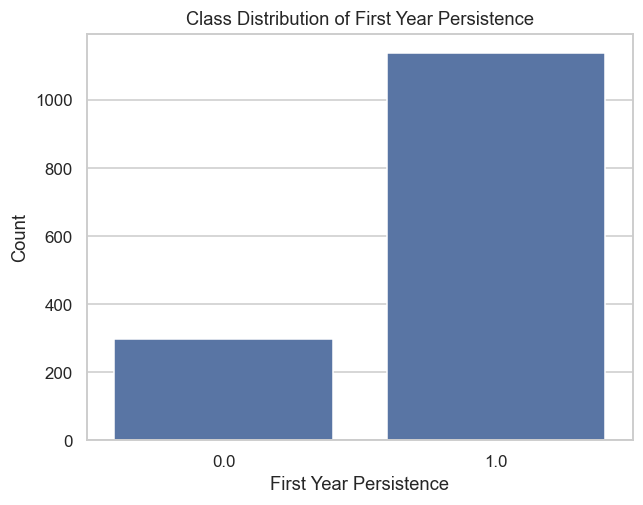

In [6]:
# target variable
target_col = "first_year_persistence"
X = clean_df.drop(columns=[target_col])
y = clean_df[target_col]

# class distribution
print("Class distribution:")
print(y.value_counts())

# plot class distribution
sns.countplot(x=y)
plt.title("Class Distribution of First Year Persistence")
plt.xlabel("First Year Persistence")
plt.ylabel("Count")
plt.show()

### Data Cleaning

In [7]:
# test-train split with stratification and train-only feature fitting
X_train_raw, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.125,  # 0.125 x 0.8 = 0.1 of the original data
    random_state=42,
    stratify=y_train,
)#10% of the original data is used for validation

# Data cleaning
cleaner = DataCleaner(numeric_imputer="random_forest")

X_train = cleaner.fit_transform(X_train)
X_val = cleaner.transform(X_val)
X_test = cleaner.transform(X_test)

C:\Vivek\Soft\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [30]:
import joblib

# save the preprocessing pipeline (DataCleaner object) to a file for later use in inference
joblib.dump(cleaner, project_path / "first_year_persistance_classification" / "models" / "preprocessing_pipeline.pkl")

# check the training after cleaning
display(X_train.head())

,first_term_gpa,second_term_gpa,school,fast_track,coop,residency,age_group,high_school_average_mark,math_score,english_grade,...,funding_2,funding_4,funding_5,funding_8,gender_1,gender_2,previous_education_0,previous_education_1,previous_education_2,previous_education_3
712,-2.395317,-2.102637,6.0,1,0,0,6.0,-0.680565,0.225035,7.0,...,False,True,False,False,True,False,False,True,False,False
203,-0.542386,0.378253,6.0,0,1,1,6.0,-1.007294,-1.395073,9.0,...,True,False,False,False,True,False,False,False,True,False
1168,-0.442848,-0.911292,6.0,0,0,1,2.0,-0.164183,-0.995540,4.0,...,True,False,False,False,False,True,False,True,False,False
1029,0.499887,0.257908,6.0,0,1,1,2.0,-1.009172,-1.594840,4.0,...,True,False,False,False,False,True,False,True,False,False
1377,-0.205490,-0.036693,6.0,1,0,0,3.0,-0.256193,0.063224,10.0,...,False,True,False,False,True,False,False,False,True,False


In [ ]:
# Check shape of the datasets after cleaning
print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (1005, 28)
Validation set shape: (144, 28)
Test set shape: (288, 28)


In [9]:
# check the final training dataset
display(X_train.head())

,first_term_gpa,second_term_gpa,school,fast_track,coop,residency,age_group,high_school_average_mark,math_score,english_grade,...,funding_2,funding_4,funding_5,funding_8,gender_1,gender_2,previous_education_0,previous_education_1,previous_education_2,previous_education_3
712,-2.395317,-2.102637,6.0,1,0,0,6.0,-0.680565,0.225035,7.0,...,False,True,False,False,True,False,False,True,False,False
203,-0.542386,0.378253,6.0,0,1,1,6.0,-1.007294,-1.395073,9.0,...,True,False,False,False,True,False,False,False,True,False
1168,-0.442848,-0.911292,6.0,0,0,1,2.0,-0.164183,-0.995540,4.0,...,True,False,False,False,False,True,False,True,False,False
1029,0.499887,0.257908,6.0,0,1,1,2.0,-1.009172,-1.594840,4.0,...,True,False,False,False,False,True,False,True,False,False
1377,-0.205490,-0.036693,6.0,1,0,0,3.0,-0.256193,0.063224,10.0,...,False,True,False,False,True,False,False,False,True,False


### Experiment 1: Baseline Model

In [ ]:
# handle class imbalance with balanced class weights
from sklearn.utils.class_weight import compute_class_weight
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))
print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(2.4043062200956937), np.int64(1): np.float64(0.6312814070351759)}


In [11]:
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout

# model architecture
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.summary()

C:\Vivek\Soft\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,161 (16.25 KB)

 Non-trainable params: 192 (768.00 B)

In [12]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
model_checkpoint = ModelCheckpoint(project_path / "first_year_persistance_classification/models/baseline_model.keras", monitor='val_loss', save_best_only=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

Epoch 1/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.6057 - loss: 0.6476 - val_accuracy: 0.7861 - val_loss: 0.4926
Epoch 2/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7027 - loss: 0.5572 - val_accuracy: 0.8308 - val_loss: 0.4950
Epoch 3/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7425 - loss: 0.4748 - val_accuracy: 0.8159 - val_loss: 0.5049
Epoch 4/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7811 - loss: 0.4497 - val_accuracy: 0.8159 - val_loss: 0.4864
Epoch 5/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7948 - loss: 0.4136 - val_accuracy: 0.7960 - val_loss: 0.4973
Epoch 6/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8060 - loss: 0.4206 - val_accuracy: 0.8308 - val_loss: 0.4283
Epoch 7/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8333 - loss: 0.3795 - val_accuracy: 0.8607 - val_loss: 0.3859
Epoch 8/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8371 - loss: 0.3814 - val_accuracy: 0.

### Baseline Evaluation

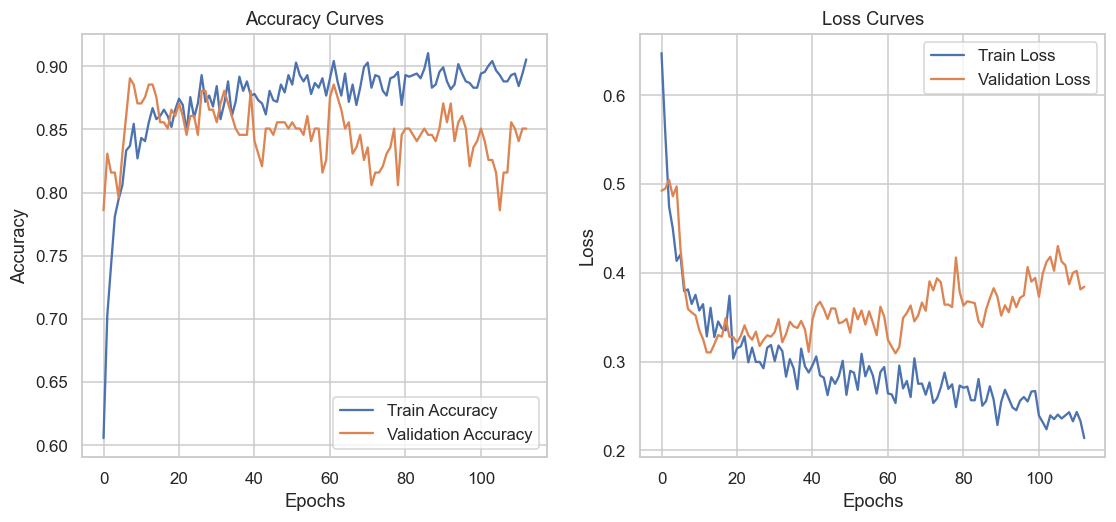

In [14]:
# plot accuracy and loss curves both val and training
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curves")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [15]:
baseline_eval_df = evaluate_classification_splits(
    model,
    [
        ("Train", X_train, y_train),
        ("Validation", X_val, y_val),
        ("Test", X_test, y_test),
    ],
    model_name="Baseline",
)
display(baseline_eval_df.round(4))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8681 - loss: 0.3352


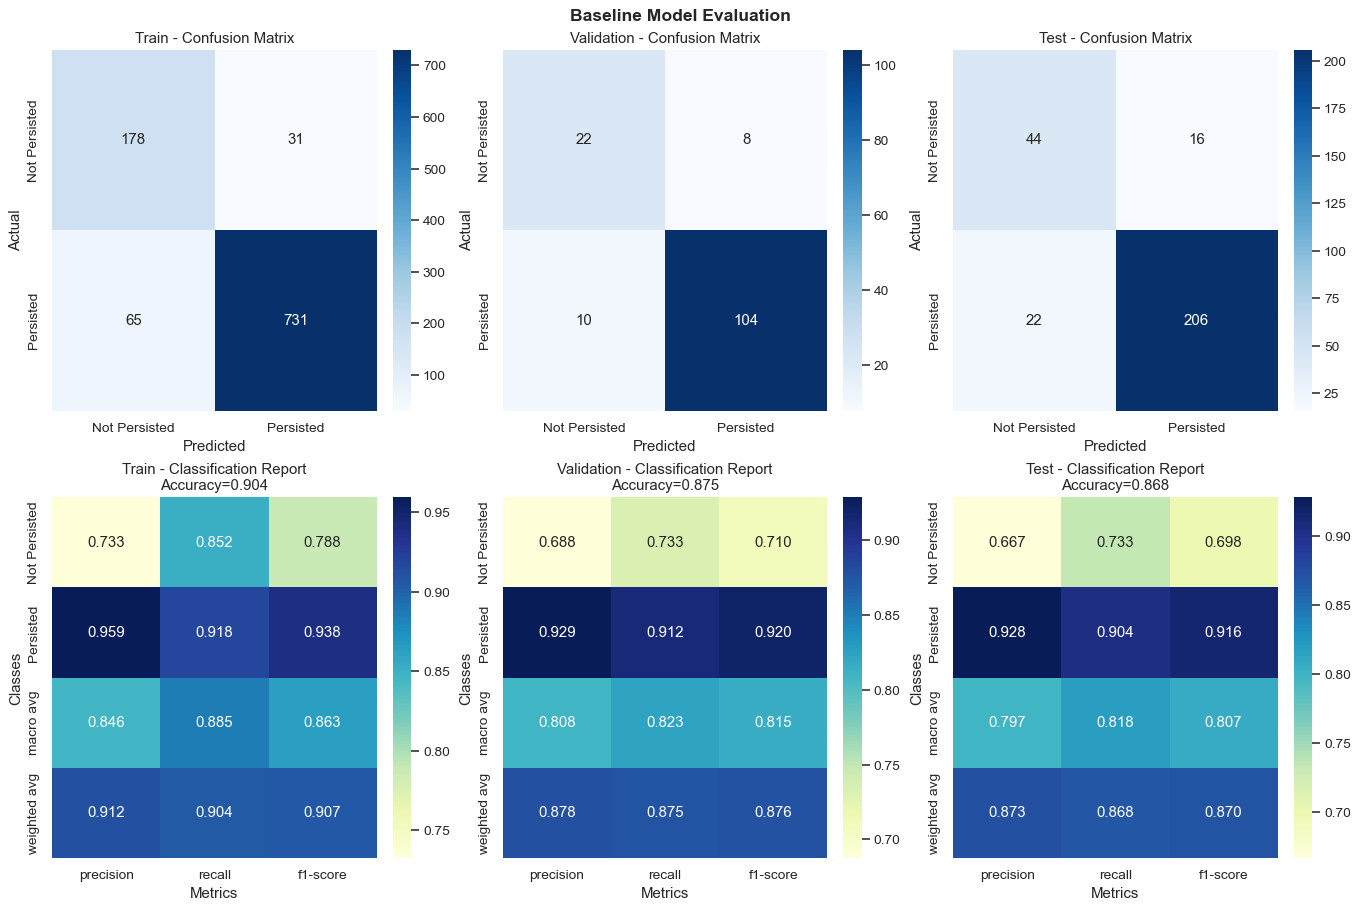

In [36]:
plot_train_test_evaluation(
    model,
    X_train_scaled=X_train,
    y_train_original=y_train,
    X_val_scaled=X_val,
    y_val_original=y_val,
    X_test_scaled=X_test,
    y_test_original=y_test,
    title="Baseline Model Evaluation",
)

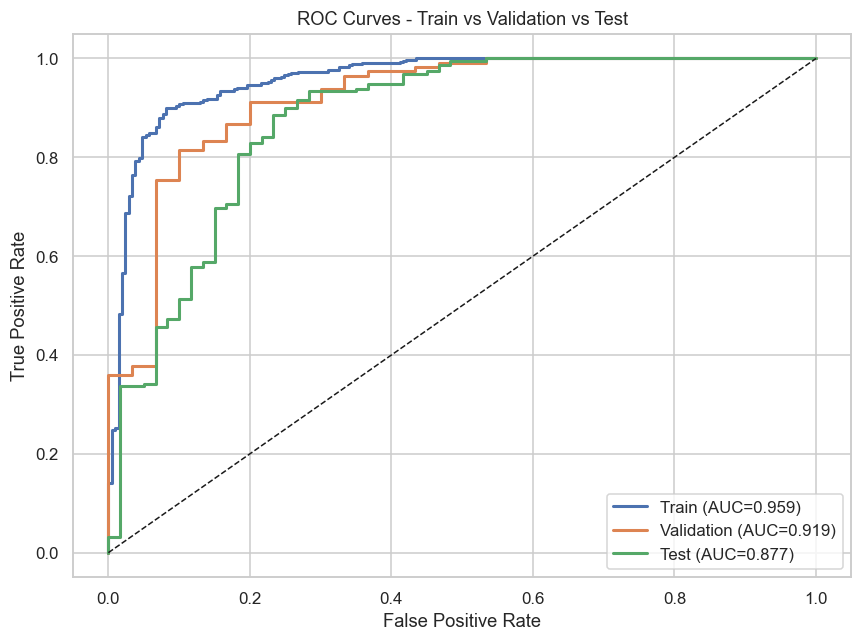

In [17]:
plot_roc_curves(
    model,
    X_train_scaled=X_train,
    y_train_original=y_train,
    X_val_scaled=X_val,
    y_val_original=y_val,
    X_test_scaled=X_test,
    y_test_original=y_test,
    title="Baseline ROC Curves",
)

,Feature Group,Accuracy Drop (Mean),Accuracy Drop (Std),AUC Drop (Mean),AUC Drop (Std),Grouped Columns
0,second_term_gpa_missing,0.093403,0.010920,0.133808,0.019187,second_term_gpa_missing
1,first_term_gpa,0.040278,0.016375,0.050490,0.012344,first_term_gpa
2,second_term_gpa,0.030903,0.014686,0.064101,0.022008,second_term_gpa
3,age_group,0.018750,0.008533,-0.002785,0.010432,age_group
4,first_language,0.018403,0.004406,0.008567,0.006519,"first_language_0, first_language_1, first_lang..."
5,funding,0.015625,0.006634,0.022215,0.008130,"funding_1, funding_2, funding_4, funding_5, fu..."
6,residency,0.005903,0.005610,0.002924,0.004381,residency
7,high_school_average_mark,0.004514,0.004406,-0.000519,0.007449,high_school_average_mark
8,fast_track,0.004167,0.005556,-0.001235,0.008365,fast_track
9,gender,0.002083,0.008812,0.008699,0.006375,"gender_1, gender_2"


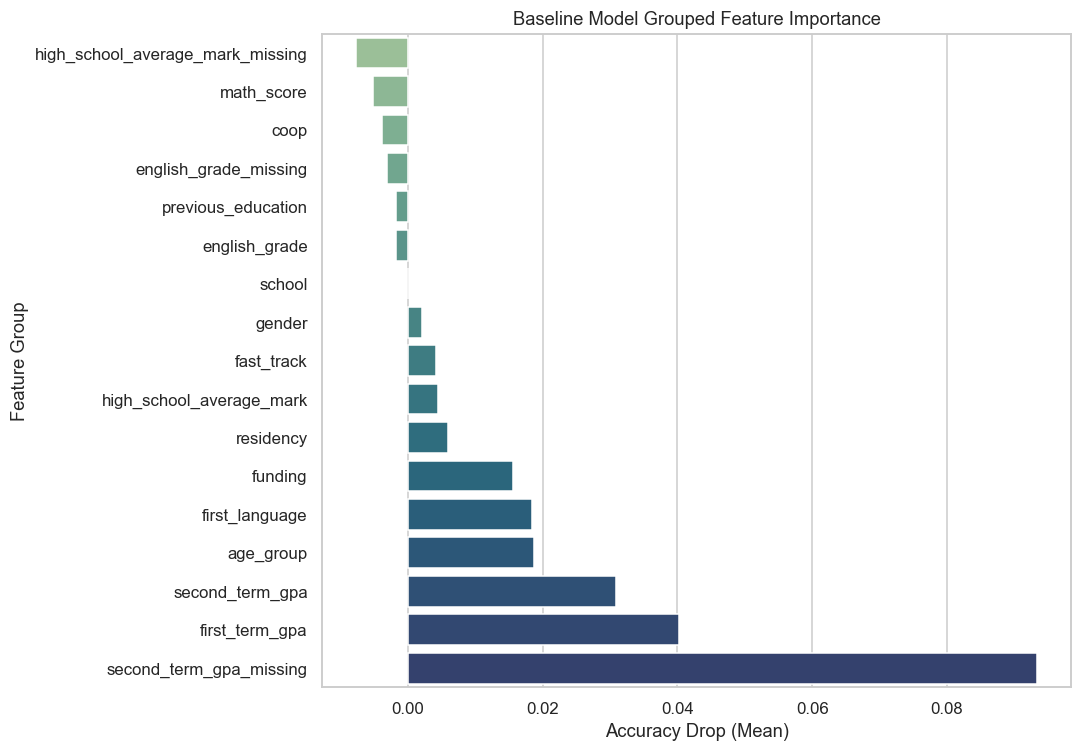

In [18]:
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def get_feature_groups(feature_columns):
    base_features = [
        "first_term_gpa",
        "second_term_gpa",
        "high_school_average_mark",
        "math_score",
        "fast_track",
        "coop",
        "residency",
        "age_group",
        "english_grade",
        "first_language",
        "funding",
        "gender",
        "previous_education",
    ]

    grouped = {}
    assigned = set()

    for feature in base_features:
        cols = [
            col for col in feature_columns
            if col == feature or (col.startswith(f"{feature}_") and not col.endswith("_missing"))
        ]
        if cols:
            grouped[feature] = cols
            assigned.update(cols)

    missing_flag_cols = [col for col in feature_columns if col.endswith("_missing")]
    for col in missing_flag_cols:
        grouped[col] = [col]
        assigned.add(col)

    for col in feature_columns:
        if col not in assigned:
            grouped[col] = [col]

    return grouped


def safe_roc_auc(y_true, y_prob):
    try:
        return float(roc_auc_score(y_true, y_prob))
    except ValueError:
        return float("nan")


def compute_grouped_permutation_importance(model, X_df, y_true, n_repeats=10, random_state=42, threshold=0.5, batch_size=256, verbose=0):
    feature_columns = list(X_df.columns)
    feature_groups = get_feature_groups(feature_columns)
    column_index = {col: idx for idx, col in enumerate(feature_columns)}

    X_values = X_df.to_numpy(dtype=np.float32, copy=True)
    y_true = np.asarray(y_true).astype(int).ravel()
    n_samples = X_values.shape[0]
    rng = np.random.default_rng(random_state)

    baseline_prob = model.predict(X_values, batch_size=batch_size, verbose=verbose).ravel()
    baseline_pred = (baseline_prob >= threshold).astype(int)
    baseline_accuracy = float(accuracy_score(y_true, baseline_pred))
    baseline_auc = safe_roc_auc(y_true, baseline_prob)

    rows = []
    for group_name, columns in feature_groups.items():
        col_idx = [column_index[col] for col in columns]
        permuted_batches = []

        for _ in range(n_repeats):
            permuted = X_values.copy()
            perm_idx = rng.permutation(n_samples)
            permuted[:, col_idx] = X_values[perm_idx][:, col_idx]
            permuted_batches.append(permuted)

        stacked = np.concatenate(permuted_batches, axis=0)
        perm_probs = model.predict(stacked, batch_size=batch_size, verbose=verbose).ravel().reshape(n_repeats, n_samples)

        accuracy_drops = []
        auc_drops = []
        for probs in perm_probs:
            preds = (probs >= threshold).astype(int)
            perm_accuracy = float(accuracy_score(y_true, preds))
            perm_auc = safe_roc_auc(y_true, probs)
            accuracy_drops.append(baseline_accuracy - perm_accuracy)
            auc_drops.append(baseline_auc - perm_auc if not (np.isnan(baseline_auc) or np.isnan(perm_auc)) else np.nan)

        rows.append({
            "Feature Group": group_name,
            "Accuracy Drop (Mean)": float(np.mean(accuracy_drops)),
            "Accuracy Drop (Std)": float(np.std(accuracy_drops)),
            "AUC Drop (Mean)": float(np.nanmean(auc_drops)) if not np.all(np.isnan(auc_drops)) else float("nan"),
            "AUC Drop (Std)": float(np.nanstd(auc_drops)) if not np.all(np.isnan(auc_drops)) else float("nan"),
            "Grouped Columns": ", ".join(columns),
        })

    importance_df = pd.DataFrame(rows).sort_values(
        ["Accuracy Drop (Mean)", "AUC Drop (Mean)"],
        ascending=False,
    ).reset_index(drop=True)
    return importance_df


def plot_grouped_feature_importance(importance_df, metric="Accuracy Drop (Mean)", title="Grouped Feature Importance"):
    plot_df = importance_df.sort_values(metric, ascending=True)
    plt.figure(figsize=(10, 7))
    sns.barplot(
        data=plot_df,
        x=metric,
        y="Feature Group",
        hue="Feature Group",
        palette="crest",
        dodge=False,
        legend=False,
    )
    plt.title(title)
    plt.xlabel(metric)
    plt.ylabel("Feature Group")
    plt.tight_layout()
    plt.show()


baseline_grouped_importance_df = compute_grouped_permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
)

display(baseline_grouped_importance_df)
plot_grouped_feature_importance(
    baseline_grouped_importance_df,
    title="Baseline Model Grouped Feature Importance",
)


### Experiment 2: Keras Tuner - Automatic Hyperband Search

In [19]:
# keras tuner hyperband define neurons, optimizers, and learning rates
import keras
from keras_tuner import Hyperband
import shutil
import time
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

def build_tuner_model(hp):
    input_dim = X_train.shape[1]
    model = keras.Sequential([keras.layers.Input(shape=(input_dim,))])

    for i in range(hp.Int("num_layers", 1, 6)):
        units = hp.Choice(f"neurons_{i}", [64, 128, 256, 512, 1024])
        activation = hp.Choice(f"act_{i}", ["relu", "tanh", "elu", "selu"])
        dropout_rate = hp.Float(f"dropout_{i}", 0.1, 0.5, step=0.2)

        model.add(Dense(units, activation=activation))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation="sigmoid"))

    opt = hp.Choice("optimizer", ["adam", "sgd", "rmsprop"])
    lr = hp.Choice("learning_rate", [0.0005, 0.001, 0.005, 0.01, 0.05, 0.1])

    if opt == "adam":
        optimizer = Adam(learning_rate=lr)
    elif opt == "sgd":
        optimizer = SGD(learning_rate=lr, momentum=0.9)
    else:
        optimizer = RMSprop(learning_rate=lr)

    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
    return model

def show_best_hyperparameters(hyperparameters):
    rows = [{"hyperparameter": key, "value": value} for key, value in hyperparameters.values.items()]
    display(pd.DataFrame(rows))

In [20]:
tuner_dir = project_path / "first_year_persistance_classification" / "tuner" / "student_tuner"
if tuner_dir.exists():
    shutil.rmtree(tuner_dir)

print("KERAS TUNER SEARCH")

hyperband_tuner = Hyperband(
    hypermodel=build_tuner_model,
    objective="val_accuracy",
    max_epochs=40,
    factor=3,
    directory=str(tuner_dir),
    project_name="student_gpa_search",
    overwrite=True,
    seed=42
)

search_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=20,
    restore_best_weights=True,
    verbose=0,
    mode="max"
 )

start_time = time.time()
hyperband_tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    class_weight=class_weights,
    callbacks=[search_stop],
    verbose=1
 )
search_time = time.time() - start_time

print(f"Search completed in {search_time / 60:.1f} minutes")
hyperband_tuner.results_summary(num_trials=10)

best_hps_list = hyperband_tuner.get_best_hyperparameters(1)
if not best_hps_list:
    raise RuntimeError("Hyperband completed without any successful trials. Check tuner logs above.")

best_hps = best_hps_list[0]
print("BEST HYPERPARAMETERS")
show_best_hyperparameters(best_hps)

Trial 90 Complete [00h 00m 34s]
val_accuracy: 0.9305555820465088

Best val_accuracy So Far: 0.9305555820465088
Total elapsed time: 00h 26m 00s
Search completed in 26.0 minutes
Results summary
Results in C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\first_year_persistance_classification\tuner\student_tuner\student_gpa_search
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0089 summary
Hyperparameters:
num_layers: 3
neurons_0: 1024
act_0: elu
dropout_0: 0.5
optimizer: sgd
learning_rate: 0.005
neurons_1: 128
act_1: selu
dropout_1: 0.1
neurons_2: 256
act_2: tanh
dropout_2: 0.5
neurons_3: 128
act_3: tanh
dropout_3: 0.5
neurons_4: 1024
act_4: tanh
dropout_4: 0.30000000000000004
neurons_5: 64
act_5: selu
dropout_5: 0.30000000000000004
tuner/epochs: 40
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.9305555820465088

Trial 0050 summary
Hyperparameters:
num_layers: 4
neurons_0: 1024
act_0: elu
dropout_0: 0.

,hyperparameter,value
0,num_layers,3
1,neurons_0,1024
2,act_0,elu
3,dropout_0,0.5
4,optimizer,sgd
5,learning_rate,0.005
6,neurons_1,128
7,act_1,selu
8,dropout_1,0.1
9,neurons_2,256


### Hyperband Results

In [ ]:
# extracting results from the search as csv with accuracy, val accuracy, loss and val loss
all_trials = list(hyperband_tuner.oracle.trials.values())

rows = []
for t in all_trials:
    hp = t.hyperparameters.values

    num_layers = hp.get('num_layers', 0)
    layer_parts = []

    for i in range(num_layers):
        neurons = hp.get(f'neurons_{i}')
        act = hp.get(f'act_{i}')
        drop = hp.get(f'dropout_{i}')
        layer_parts.append(f"{neurons}-{act}-Drop{drop}")

    architecture = f"{num_layers}L-" + "-".join(layer_parts)
    experiment = f"{architecture}-{hp.get('optimizer')}-LR{hp.get('learning_rate')}"

    rows.append({
        "Experiment": experiment,
        "Accuracy": t.metrics.metrics["accuracy"].get_best_value()
            if "accuracy" in t.metrics.metrics else None,
        "Loss": t.metrics.metrics["loss"].get_best_value()
            if "loss" in t.metrics.metrics else None,
        "Val_Accuracy": t.metrics.metrics["val_accuracy"].get_best_value()
            if "val_accuracy" in t.metrics.metrics else None,
        "Val_Loss": t.metrics.metrics["val_loss"].get_best_value()
            if "val_loss" in t.metrics.metrics else None,
        "Epochs": hp.get('tuner/epochs'),
        "Trial_ID": t.trial_id
    })

results_df = pd.DataFrame(rows).sort_values("Val_Accuracy", ascending=False)
results_df.insert(0, "ID", range(1, len(results_df) + 1))

results_df.to_csv(
    project_path / "keras_tuner_results.csv",
    index=False
)

In [22]:
print("TOP 20 BEST TRIALS (by Validation Accuracy)")
print(results_df.head(20).to_string(index=False))

TOP 20 BEST TRIALS (by Validation Accuracy)
 ID                                                                                                                                                                            Experiment  Accuracy     Loss  Val_Accuracy  Val_Loss  Epochs Trial_ID
  1                                                                                                                     3L-1024-elu-Drop0.5-128-selu-Drop0.1-256-tanh-Drop0.5-sgd-LR0.005  0.809950 0.450404      0.930556  0.328276      40     0089
  2                                                                5L-128-elu-Drop0.30000000000000004-1024-relu-Drop0.1-512-elu-Drop0.5-256-elu-Drop0.5-256-selu-Drop0.1-rmsprop-LR0.0005  0.849751 0.374366      0.923611  0.277521      40     0085
  3                                                                       5L-256-tanh-Drop0.1-64-elu-Drop0.30000000000000004-512-relu-Drop0.5-64-selu-Drop0.5-1024-elu-Drop0.5-sgd-LR0.01  0.748259 0.854031      0.923611

### Experiment 3: Best Hyperband Model

In [117]:
# best model from the search high accuracy and low loss on validation set
overall_best_trial = hyperband_tuner.get_best_hyperparameters(11)[10]
best_model = hyperband_tuner.hypermodel.build(overall_best_trial)
best_model.summary()

# observe training with early stopping and model checkpointing
best_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=20,
    restore_best_weights=True,
    verbose=0,
    mode="max",
)

checkpoint = ModelCheckpoint(
    filepath=project_path / "first_year_persistance_classification/models/best_model_tuner.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
)

history = best_model.fit(
    X_train, y_train,
    epochs=200,
    class_weight=class_weights,
    validation_data=(X_val, y_val),
    callbacks=[best_stop, checkpoint],
    verbose=1,
)

print("Training completed.")

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_83 (Dense)                     │ (None, 256)                 │           7,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_65               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_65 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_84 (Dense)                     │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_66               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_66 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_85 (Dense)                     │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_67               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_67 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_86 (Dense)                     │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_68               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_68 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_87 (Dense)                     │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 209,153 (817.00 KB)

 Trainable params: 207,105 (809.00 KB)

 Non-trainable params: 2,048 (8.00 KB)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.7015 - loss: 0.8607 - val_accuracy: 0.8264 - val_loss: 0.6110
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7692 - loss: 0.5009 - val_accuracy: 0.8819 - val_loss: 0.3745
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8080 - loss: 0.4771 - val_accuracy: 0.8611 - val_loss: 0.3781
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8507 - loss: 0.4211 - val_accuracy: 0.9097 - val_loss: 0.2914
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8229 - loss: 0.4289 - val_accuracy: 0.8750 - val_loss: 0.3108
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8458 - loss: 0.4132 - val_accuracy: 0.9167 - val_loss: 0.2686
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8507 - loss: 0.3979 - val_accuracy: 0.8889 - val_loss: 0.3234
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8517 - loss: 0.4032 - val_accuracy: 0

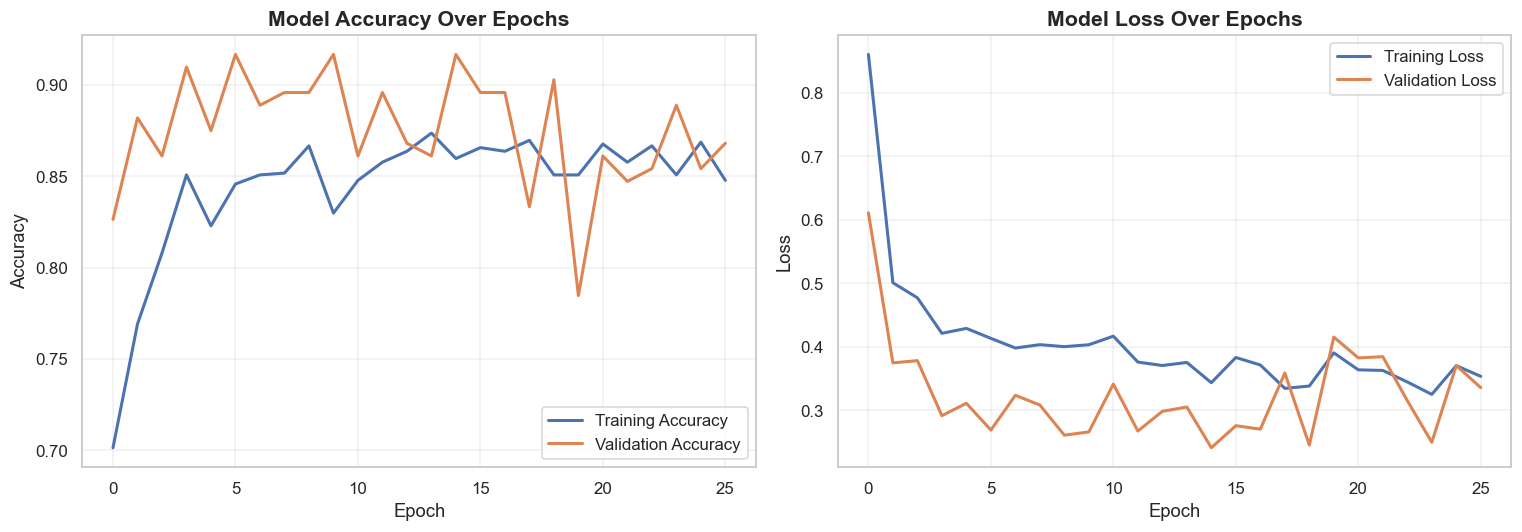


Best Epoch: 6 | Train Acc: 0.8458 | Val Acc: 0.9167 | Train Loss: 0.4132 | Val Loss: 0.2686


In [118]:
def plot_acc_loss_graph(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot accuracy
    axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot loss
    axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    def best_metric(name, best):
        return f"{history.history[name][best]:.4f}"

    best = int(np.argmax(history.history['val_accuracy']))

    print( f"\nBest Epoch: {best+1} | Train Acc: {best_metric('accuracy', best)} | Val Acc: {best_metric('val_accuracy', best)} | "
        f"Train Loss: {best_metric('loss', best)} | Val Loss: {best_metric('val_loss', best)}")
# visualize training history 
plot_acc_loss_graph(history)

### Best Model Evaluation

In [119]:
best_eval_df = evaluate_classification_splits(
    best_model,
    [
        ("Train", X_train, y_train),
        ("Validation", X_val, y_val),
        ("Test", X_test, y_test),
    ],
    model_name="Hyperband Best",
)
display(best_eval_df.round(4))

,Model,Split,Loss,Accuracy,Precision,Recall,F1,ROC AUC
0,Hyperband Best,Train,0.2722,0.8975,0.9358,0.9347,0.9353,0.9305
1,Hyperband Best,Validation,0.2686,0.9167,0.9322,0.9649,0.9483,0.9354
2,Hyperband Best,Test,0.2902,0.8958,0.9267,0.9430,0.9348,0.9166


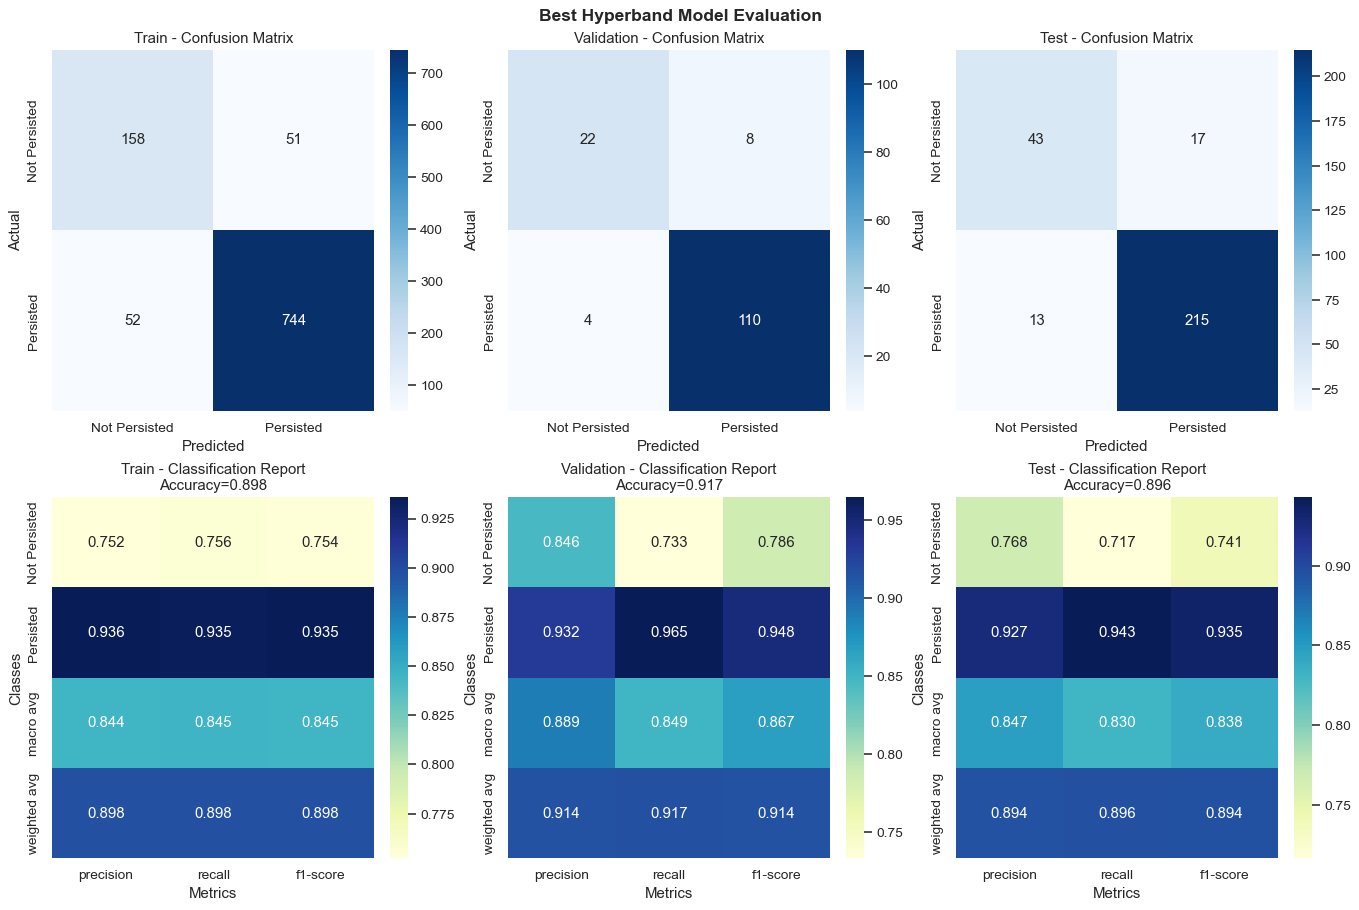

In [120]:
plot_train_test_evaluation(
    best_model,
    X_train_scaled=X_train,
    y_train_original=y_train,
    X_val_scaled=X_val,
    y_val_original=y_val,
    X_test_scaled=X_test,
    y_test_original=y_test,
    title="Best Hyperband Model Evaluation",
)

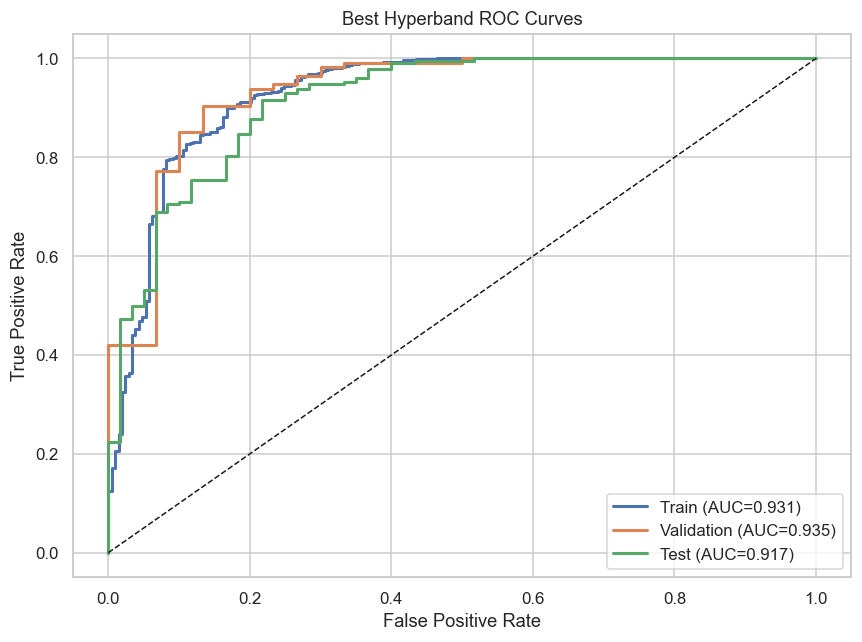

In [121]:
plot_roc_curves(
    best_model,
    X_train_scaled=X_train,
    y_train_original=y_train,
    X_val_scaled=X_val,
    y_val_original=y_val,
    X_test_scaled=X_test,
    y_test_original=y_test,
    title="Best Hyperband ROC Curves",
)

### Model Comparison

,Model,Split,Loss,Accuracy,Precision,Recall,F1,ROC AUC
0,Baseline,Train,0.2164,0.9045,0.9593,0.9183,0.9384,0.9586
1,Baseline,Validation,0.2896,0.8750,0.9286,0.9123,0.9204,0.9187
2,Baseline,Test,0.3352,0.8681,0.9279,0.9035,0.9156,0.8774
3,Hyperband Best,Train,0.2722,0.8975,0.9358,0.9347,0.9353,0.9305
4,Hyperband Best,Validation,0.2686,0.9167,0.9322,0.9649,0.9483,0.9354
5,Hyperband Best,Test,0.2902,0.8958,0.9267,0.9430,0.9348,0.9166


,Model,Loss,Accuracy,Precision,Recall,F1,ROC AUC
0,Hyperband Best,0.2902,0.8958,0.9267,0.9430,0.9348,0.9166
1,Baseline,0.3352,0.8681,0.9279,0.9035,0.9156,0.8774


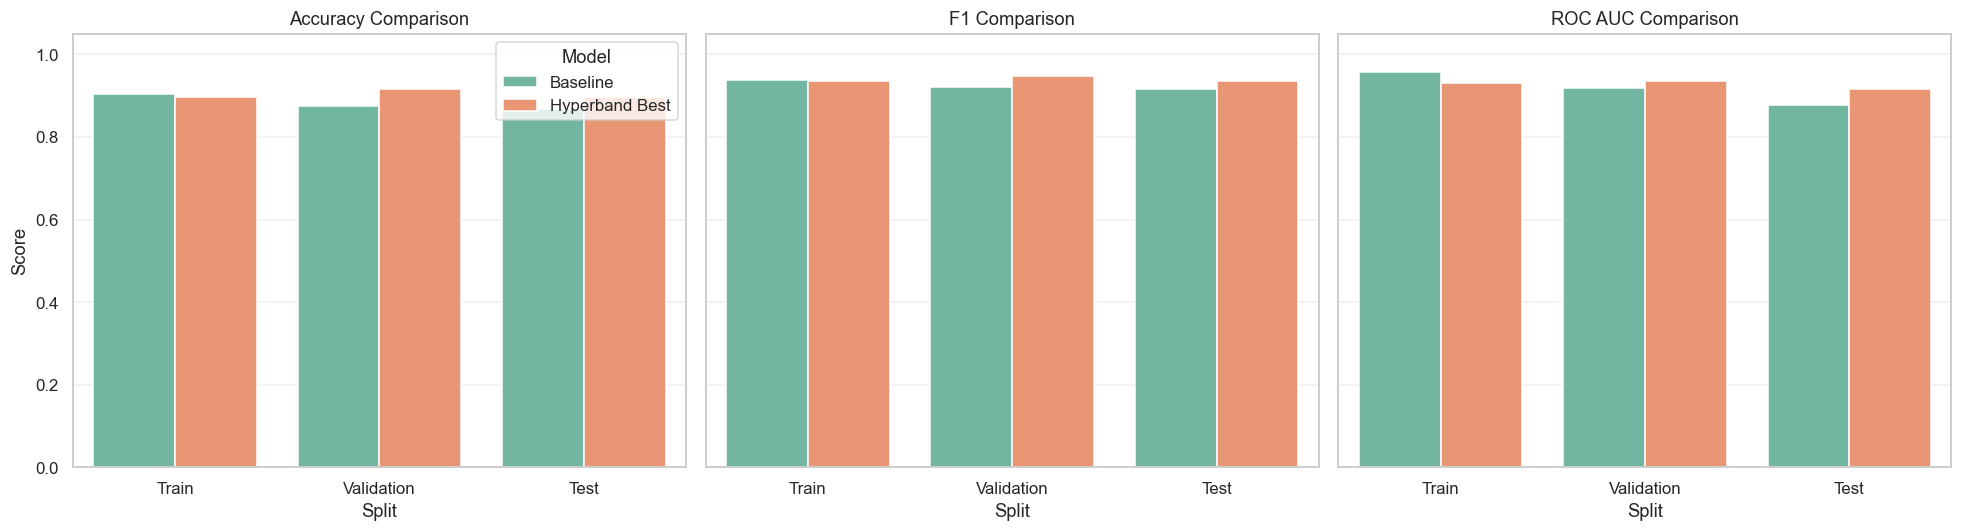

In [122]:
comparison_df = pd.concat(
    [
        evaluate_classification_splits(
            model,
            [("Train", X_train, y_train), ("Validation", X_val, y_val), ("Test", X_test, y_test)],
            model_name="Baseline",
        ),
        evaluate_classification_splits(
            best_model,
            [("Train", X_train, y_train), ("Validation", X_val, y_val), ("Test", X_test, y_test)],
            model_name="Hyperband Best",
        ),
    ],
    ignore_index=True,
)
comparison_display_df = comparison_df.copy()
comparison_display_df[["Loss", "Accuracy", "Precision", "Recall", "F1", "ROC AUC"]] = comparison_display_df[["Loss", "Accuracy", "Precision", "Recall", "F1", "ROC AUC"]].round(4)

display(comparison_display_df)

test_rank_df = comparison_df[comparison_df["Split"] == "Test"].sort_values(
    by=["Accuracy", "F1", "ROC AUC"],
    ascending=False,
).reset_index(drop=True)

display(test_rank_df[["Model", "Loss", "Accuracy", "Precision", "Recall", "F1", "ROC AUC"]].round(4))

plot_df = comparison_df.melt(
    id_vars=["Model", "Split"],
    value_vars=["Accuracy", "F1", "ROC AUC"],
    var_name="Metric",
    value_name="Score",
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, metric in zip(axes, ["Accuracy", "F1", "ROC AUC"]):
    sns.barplot(
        data=plot_df[plot_df["Metric"] == metric],
        x="Split",
        y="Score",
        hue="Model",
        palette="Set2",
        ax=ax,
    )
    ax.set_title(f"{metric} Comparison")
    ax.set_xlabel("Split")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.grid(True, axis="y", alpha=0.3)
    if ax is not axes[0]:
        ax.legend_.remove()

axes[0].legend(title="Model")
plt.tight_layout()
plt.show()


### Grouped Feature Importance

,Feature Group,Accuracy Drop (Mean),Accuracy Drop (Std),AUC Drop (Mean),AUC Drop (Std),Grouped Columns
0,second_term_gpa_missing,0.097569,0.010236,0.100431,0.013668,second_term_gpa_missing
1,second_term_gpa,0.034722,0.013714,0.064883,0.015332,second_term_gpa
2,first_term_gpa,0.032639,0.012634,0.046294,0.008407,first_term_gpa
3,math_score,0.012847,0.010651,0.003494,0.002834,math_score
4,first_language,0.003819,0.003625,0.002456,0.003070,"first_language_0, first_language_1, first_lang..."
5,funding,0.003472,0.003804,0.014064,0.006969,"funding_1, funding_2, funding_4, funding_5, fu..."
6,previous_education,0.003125,0.001870,0.001747,0.001520,"previous_education_0, previous_education_1, pr..."
7,residency,0.002083,0.002778,-0.000928,0.003619,residency
8,coop,0.001736,0.001736,-0.000636,0.000910,coop
9,high_school_average_mark_missing,0.001042,0.002223,-0.002412,0.001161,high_school_average_mark_missing


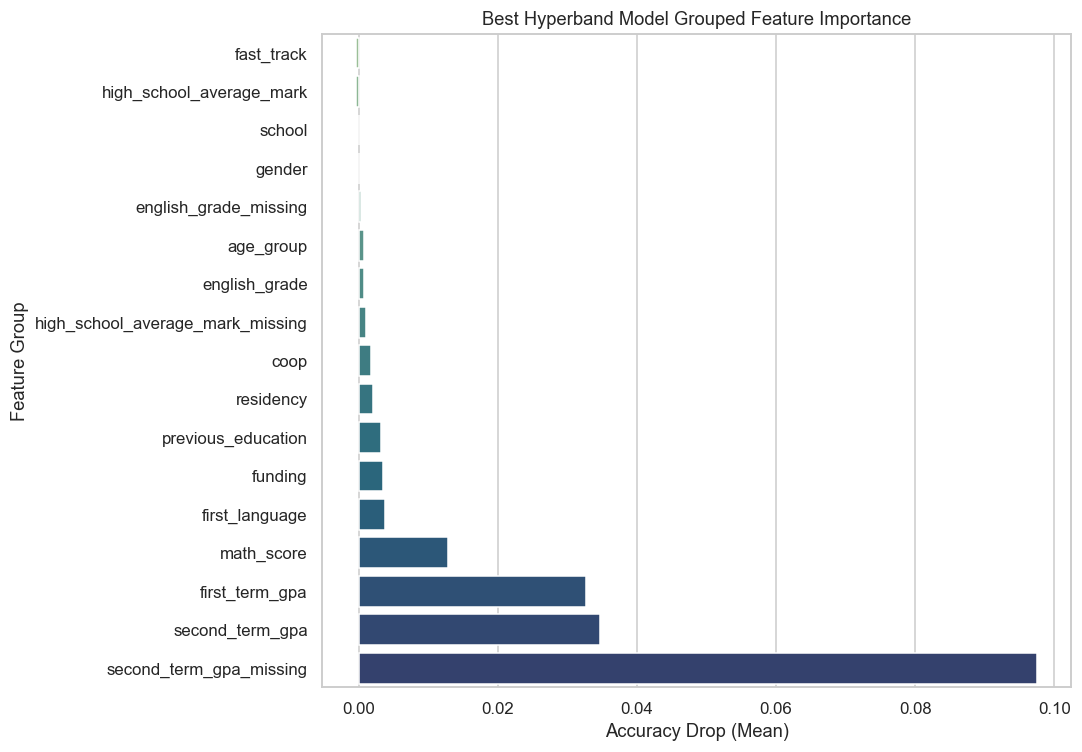

In [123]:
best_grouped_importance_df = compute_grouped_permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
)

display(best_grouped_importance_df)
plot_grouped_feature_importance(
    best_grouped_importance_df,
    title="Best Hyperband Model Grouped Feature Importance",
)
